In [3]:
library(ggplot2)
library(dplyr)
library(gridExtra)
library(cowplot)
library(ggrepel)
library(grid)
library(ggsci)
library(ComplexHeatmap)
library(circlize)

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘gridExtra’ was built under R version 4.3.3”

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Warning message:
“package ‘cowplot’ was built under R version 4.3.3”
Warning message:
“package ‘ggrepel’ was built under R version 4.3.3”
Warning message:
“package ‘ggsci’ was built under R version 4.3.3”
Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.3.2”
ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap

In [3]:
# load("/vol/projects/yzhang/500FG_aging/output/18_multi_omics_heatmap/multi_omics_heatmap.Rdata")

In [4]:
methylation <- readRDS("/vol/projects/yzhang/500FG_aging/output/05_methylation/methylation_age_liner_gender_FDR.RDS")
methylation <- methylation %>% rename(feature = Mvalue)
head(methylation)

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,cg00381604_BC11,-0.0013622451,0.41563686,-0.0005194049,0.7068243,no
Estimate1,cg00002271_BC21,-0.0013741588,0.11639210,-0.0012835694,0.3701592,no
Estimate2,cg00004581_TC21,0.0014710346,0.37799659,0.0006215299,0.6769167,no
Estimate3,cg09261435_BC21,-0.0011294722,0.55554164,-0.0002883355,0.8019698,no
Estimate4,cg00005473_TC21,-0.0007555015,0.38875621,-0.0003099994,0.6857682,no
Estimate5,cg00005474_TC21,0.0027755478,0.02548049,0.0044236464,0.1469979,no


In [5]:
table(methylation$sig)


    no    sig 
763303  91065 

In [6]:
methylation_filtered <- methylation[methylation$padj < 0.0001 & 
                                     abs(methylation$estimate) > 0.02, ]
dim(methylation_filtered)

[1] 203   6

In [7]:
olink <- read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/olink_age_liner_gender_FDR.csv",row.names=1)  #age not scale
cytokine <- read.csv("/vol/projects/yzhang/500FG_aging/output/01_cytokine/cytokine_age_liner_gender_FDR.csv",row.names=1) #age not scale
metabolite <- read.csv("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_age_linear_gender_FDR.csv",row.names=1) #age not scale
hormone <- read.csv("/vol/projects/yzhang/500FG_aging/output/06_hormone/hormone_age_liner_gender_FDR.csv",row.names=1) ##age not scale
cellcounts <- read.csv("/vol/projects/yzhang/500FG_aging/output/07_cellcounts/cellcounts_age_rawless_gender_FDR.csv",row.names=1)  ##age not scale
immunoglobulin <- read.csv("/vol/projects/yzhang/500FG_aging/output/08_immunoglobulin/immunoglobulin_age_gender_FDR.csv",row.names=1) ##age not scale
microbiome <- read.csv("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_age_gender_FDR.csv",row.names=1) ##age not scale

head(olink)
head(cytokine)
head(metabolite)
head(cellcounts)
head(microbiome)
head(hormone)
head(immunoglobulin)

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IL8,1.857226e-03,1.605897e-07,1.261852e-02,1.405159e-06,sig
Estimate1,VEGFA,3.326290e-04,2.074781e-03,8.924529e-04,6.051445e-03,sig
Estimate2,CD8A,-1.732231e-03,1.947852e-06,-9.891808e-03,1.136247e-05,sig
Estimate3,CDCP1,8.233146e-03,1.164648e-42,3.452471e-01,8.152538e-41,sig
Estimate4,CD244,-1.948333e-05,9.125587e-01,-7.742512e-07,9.257842e-01,no
Estimate5,IL7,1.341586e-03,3.960574e-02,1.881228e-03,7.108723e-02,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IFNy_LPS_WB_48h,-1.489589e-03,0.0157429534,-2.685600e-03,0.057304350,no
Estimate1,IFNy_PHA_WB_48h,-1.248407e-03,0.1019912047,-1.237717e-03,0.257610692,no
Estimate2,IFNy_C.conidiaHK_WB_48h,-2.449299e-03,0.0004847994,-8.118050e-03,0.002757296,sig
Estimate3,IFNy_S.aureus_WB_48h,-1.828313e-03,0.0112181557,-3.565355e-03,0.050387503,no
Estimate4,IL1b_LPS_WB_48h,1.086956e-04,0.5573738995,2.759275e-05,0.768500377,no
Estimate5,IL1b_PHA_WB_48h,-9.867128e-05,0.8021676676,-9.446280e-06,0.912465722,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Deoxynivalenol,-0.0021935538,1.463405e-02,-4.024372e-03,3.879725e-02,sig
Estimate1,Xenognosin A,0.0043140324,1.653234e-08,3.357036e-02,2.748502e-07,sig
Estimate2,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,-0.0022477068,8.116900e-02,-2.451371e-03,1.577902e-01,no
Estimate3,Cymarose,0.0002078031,6.635199e-01,3.701929e-05,7.537209e-01,no
Estimate4,Digitalose,0.0009722504,7.081403e-02,1.117972e-03,1.407462e-01,no
Estimate5,2-Naphthol,-0.0009047130,1.127605e-01,-8.575259e-04,2.036774e-01,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Granulocytes,0.0053116240,6.575255e-04,1.690205e-02,1.919974e-03,sig
Estimate1,Monocytes (CD14+),0.0027371700,1.226924e-01,2.494061e-03,1.722413e-01,no
Estimate2,Classical monocytes (CD14++CD16-),0.0003365318,8.606286e-01,2.193657e-05,9.105201e-01,no
Estimate3,Non-classical monocytes (CD14++CD16+),0.0106594533,7.996762e-07,6.499160e-02,3.441537e-06,sig
Estimate4,Intermediate monocytes (CD14+CD16+),0.0112041293,2.481781e-08,8.521005e-02,2.013000e-07,sig
Estimate5,T cells (CD3+ CD56-),-0.0056417279,1.308008e-04,-2.190903e-02,4.151505e-04,sig


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,PWY.6834..spermidine.biosynthesis.III,1.296846e-05,0.9545314,2.620895e-07,0.9976798,no
Estimate1,FERMENTATION.PWY..mixed.acid.fermentation,-5.972001e-04,0.6202431,-1.238820e-04,0.9976798,no
Estimate2,PWY.5686..UMP.biosynthesis,1.007802e-04,0.7923674,1.018620e-05,0.9976798,no
Estimate3,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,-2.188349e-05,0.9326019,-6.631511e-07,0.9976798,no
Estimate4,VALDEG.PWY..L.valine.degradation.I,3.496102e-06,0.9947422,8.004158e-09,0.9976798,no
Estimate5,PPGPPMET.PWY..ppGpp.biosynthesis,1.820142e-03,0.6194021,3.786394e-04,0.9976798,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,B_ADNC,-0.02501094,4.283096e-26,-0.63448350,3.854787e-25,sig
Estimate1,B_CORC,-0.02015736,2.037838e-17,-0.33644307,9.170270e-17,sig
Estimate2,B_DESC,-0.02048826,3.050586e-07,-0.13349364,6.663984e-07,sig
Estimate3,B_OHP,-0.01130764,3.791113e-03,-0.02737844,4.874289e-03,sig
Estimate4,B_PROG,-0.01576901,3.129267e-03,-0.03949439,4.693901e-03,sig
Estimate5,B_TESC,-0.01334730,2.096557e-09,-0.11583443,6.289670e-09,sig


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IgG,-0.0008073224,0.4688979843,-0.0002655458,0.5358834106,no
Estimate1,IgA,0.0108772125,0.0001071556,0.0431823702,0.0008572451,sig
Estimate2,IgM,-0.0053371194,0.0352829504,-0.0077518196,0.0705659008,no
Estimate3,IgG1,-0.0028358536,0.0174610334,-0.0049852323,0.0465627556,sig
Estimate4,IgG2,0.0061802909,0.0008521803,0.0189702083,0.0034087213,sig
Estimate5,IgG3,-0.0035759784,0.1547176510,-0.0028981880,0.2475482415,no


In [8]:
Mvalue_raw <- readRDS("/vol/projects/yzhang/500FG_aging/input/methylation/Mvalue_trans.rds")
head(Mvalue_raw)
dim(Mvalue_raw)

,cg00381604_BC11,cg00002271_BC21,cg00004581_TC21,cg09261435_BC21,cg00005473_TC21,cg00005474_TC21,cg05728515_BC21,cg16535257_BC21,cg06402284_TC21,cg23803172_BC11,⋯,cg25650340_BC21,cg15272228_BC21,cg13801850_TC21,cg08423507_BC11,cg00417056_TC21,cg26569416_BC21,cg00836251_TC11,cg19565306_TC11,cg26570081_BC21,cg26570107_TC11
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,-2.237989,-0.238163308,-0.8471488,-2.650742,2.832162,2.989058,-0.06371794,-1.2475431,-3.171333,-1.945719,⋯,1.792027,2.846058,2.674798,3.557235,2.175049,2.486616,0.5058024,-3.357809,0.24714223,1.937447
HV028,-2.993832,0.179353075,-0.7458927,-3.477874,2.713003,2.786193,-0.17542926,-0.9597089,-3.081547,-2.526953,⋯,1.301469,2.266840,2.651813,3.534698,2.402969,2.548605,0.4882823,-3.510284,0.27900806,2.886805
HV029,-2.809308,0.002355801,-1.2237578,-2.444885,2.777878,3.308482,-0.07947675,-1.3558920,-3.519463,-2.232778,⋯,1.467730,2.997252,2.575661,3.516068,2.391611,2.223360,0.5248776,-3.653935,0.51816098,2.653762
HV030,-3.595715,-0.010787865,-0.5750968,-1.425154,2.586534,2.705623,-0.10720149,0.7144217,-2.746095,-2.265159,⋯,1.723641,2.310457,2.405187,3.740006,2.172605,2.211940,0.4392715,-4.623792,0.39271559,2.503377
HV031,-3.278892,0.167449136,-1.0373727,-2.589345,2.931423,3.311266,-0.14057353,-0.7572419,-3.493002,-3.084362,⋯,1.480579,3.102829,2.581876,2.843706,2.280049,2.052335,0.5931438,-4.106105,0.06987152,1.272119
HV032,-2.785710,0.228439203,-0.4863300,-3.266611,2.553519,2.709708,-0.09994364,-0.1787035,-2.979256,-2.418907,⋯,1.641023,2.578209,2.425178,3.864622,2.069453,1.602279,0.5065401,-4.478348,0.37067226,2.815332


[1]    306 854368

In [9]:
Mvalue_subset <- Mvalue_raw[, colnames(Mvalue_raw) %in% methylation_filtered$feature]
head(Mvalue_subset)
dim(Mvalue_subset)

,cg07540520_TC11,cg00345951_TC11,cg12634306_TC11,cg27447795_BC21,cg18815943_TC11,cg01281911_TC11,cg07914614_TC21,cg26885220_TC11,cg23923856_TC11,cg01885725_BC21,⋯,cg14121816_BC21,cg18645241_BC21,cg26159095_TC21,cg26159096_TC21,cg26192114_BC21,cg07274898_TC11,cg02487453_TC11,cg12158483_BC11,cg06268694_TC11,cg00884093_BC11
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,-2.8904581,3.497210,0.10525472,-0.6077604,-2.7846213,-1.225653,0.9091897,-2.671059,-3.4257905,0.5577257,⋯,1.870147,1.1132852,-0.83486459,0.34829011,0.3949678,-0.5014877,-3.188364,-2.260789,-2.2167899,-1.444708
HV028,-0.9577640,2.415793,-0.56523184,-0.8035828,-0.8861011,-2.059654,0.9859541,-2.470013,-0.8631446,0.5358764,⋯,3.379044,0.7940364,-0.85665040,0.11427458,0.7796526,-1.5609878,-2.906045,-1.980903,-1.5618450,-1.427182
HV029,-2.5047442,4.567796,0.62558511,-1.4157016,-1.7856949,-2.183441,0.6490047,-2.911822,-2.3054278,0.3085178,⋯,3.303630,0.1379063,-1.57165972,-0.62410610,0.4525541,-0.4875908,-3.051400,-1.909870,-0.6216551,-1.681546
HV030,-0.5044454,1.690327,1.29504456,-0.2956847,-2.9222256,-3.625473,1.8292621,-3.622257,-2.6792219,1.6399896,⋯,3.206317,1.4397851,0.05129088,1.66840284,0.3178540,-2.3461760,-3.161343,-3.390383,-3.4545175,-3.864599
HV031,-2.0246149,3.795856,-0.03489586,-1.4837422,-3.3856358,-2.133447,0.8849452,-3.067118,-2.5571175,0.6352151,⋯,2.219785,0.5492881,-1.07260241,0.04863458,0.2375577,-1.8068771,-0.404455,-3.075244,-0.9866772,-1.874731
HV032,-2.2905633,4.123871,1.42777763,-0.7840431,-3.2561171,-2.408092,1.0974358,-2.986698,-2.0978744,0.7500991,⋯,1.827918,0.4317477,-0.81547744,-0.27179015,-0.2413773,-1.1710707,-3.302403,-0.576545,-1.0612173,-1.508260


[1] 306 203

In [10]:
Mvalue_raw <- NULL
rm(Mvalue_raw)

In [11]:
olink_raw  <- readRDS("/vol/projects/CIIM/cohorts_old/500FG/olinkData/NPX_FG500.RDS")
head(olink_raw)
dim(olink_raw)
cytokine_raw <- read.csv("/vol/projects/yzhang/500FG_aging/input/cytokine/filtered_cytokine_filled_trans.csv",row.names=1)
head(cytokine_raw)
dim(cytokine_raw)
metabolite_raw <- readRDS("/vol/projects/yzhang/500FG_aging/input/metabolite/metabolite_trans.rds")
head(metabolite_raw)
dim(metabolite_raw)
hormone_raw <- read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_log2_hormone_levels.txt", header = TRUE, sep = "", stringsAsFactors = FALSE)
head(hormone_raw)
dim(hormone_raw)
cellcounts_raw <- read.csv("/vol/projects/yzhang/500FG_aging/input/cellCounts/cellcounts_name_replace.csv",row.names=1,check.names = FALSE)
head(cellcounts_raw)
dim(cellcounts_raw)
microbiome_raw <- read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_microbiome_pathways.txt", header = TRUE, sep = "", stringsAsFactors = FALSE)
head(microbiome_raw)
dim(microbiome_raw)
immunoglobulin_raw <- read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_log2_immunoglobulin_levels.txt", header = TRUE, sep = "", stringsAsFactors = FALSE)
head(immunoglobulin_raw)
dim(immunoglobulin_raw)

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,CX3CL1,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1
HV001,3.63611,9.48365,9.52098,2.30522,7.29957,2.53580,9.68034,6.69739,9.83187,2.65429,⋯,5.09046,6.45090,2.70225,9.03842,8.68959,3.22945,4.78947,4.93394,4.44519,9.53556
HV002,4.31364,9.69720,10.49119,1.97309,7.34675,3.16577,10.23258,7.63274,10.44883,2.01410,⋯,5.44641,6.73492,2.76555,9.75981,6.22762,4.50936,5.30881,5.22062,4.81664,9.72443
HV003,4.06539,10.19810,9.57446,2.28619,7.46174,2.91413,10.33496,7.45751,9.80417,3.37359,⋯,6.08994,6.77356,2.77692,8.77353,6.15381,4.79457,5.47104,5.15920,5.64723,10.37471
HV004,3.20146,9.97967,7.86780,2.22472,6.33368,2.29093,9.83527,6.53851,9.56768,3.32486,⋯,5.59638,6.68823,2.44064,8.87093,5.66952,4.72120,4.61117,5.74346,5.96514,10.25552
HV005,4.28828,10.10370,11.63828,2.26651,7.93486,3.32575,9.80797,7.58017,10.16342,2.64213,⋯,6.07405,7.26541,2.69546,9.52142,7.18970,4.65843,5.87574,5.37253,5.17238,9.85607
HV006,4.21672,10.11105,11.17692,2.53762,7.29801,2.96055,10.59224,6.94480,10.04118,2.97745,⋯,6.00473,7.15083,2.69737,9.67547,6.45433,3.70019,4.68181,5.17577,5.08267,9.98597


[1] 424  70

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Cryptococcus_PBMC_7days,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,10.828930,10.710806,8.965784,10.366322,11.34541,10.595257,8.392317,10.051209,13.26033,13.03480,⋯,NA,8.290019,8.335390,7.936638,8.005625,10.152285,7.459432,8.326429,6.285402,9.417853
HV002,9.457381,8.761551,9.511753,9.651052,11.43359,9.652845,8.558421,9.162391,13.74431,12.81238,⋯,NA,10.594325,10.156083,9.703904,9.142107,4.954196,8.927778,9.579316,7.149747,6.285402
HV003,8.413628,10.884934,5.857981,8.442943,11.03480,10.098032,7.475733,9.321928,12.89045,12.62708,⋯,NA,11.640697,8.467606,8.857981,8.927778,10.637531,9.592457,10.224002,8.654636,11.734710
HV004,5.643856,5.285402,5.285402,5.426265,10.69697,8.894818,10.008429,9.238405,13.48533,13.11586,⋯,NA,11.611486,8.224002,7.851749,9.079485,10.795228,8.129283,8.654636,7.781360,10.781360
HV005,8.957102,8.179909,5.700440,7.459432,10.68299,9.105909,7.475733,9.396605,13.04405,12.66977,⋯,NA,NA,7.845490,6.149747,7.864186,9.829723,6.285402,7.149747,6.507795,9.529431
HV006,8.774787,6.727920,5.781360,7.483816,10.22641,7.599913,6.266787,8.761551,12.75572,12.06205,⋯,NA,10.087463,7.876517,7.303781,8.921841,10.710806,7.930737,7.375039,7.149747,9.946906


[1] 489  91

,Deoxynivalenol,Xenognosin A,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,Cymarose,Digitalose,2-Naphthol,5-Hydroxy-7-(4-hydroxy-3-methoxyphenyl)-1-phenyl-3-heptanone,"N,N'-Diacetylchitobiosyldiphosphodolichol",10-Undecenal,Vitamin A,⋯,Dihydroisomorphine-3-glucuronide,"7,11-Bisdeacetylvaltrate 7-(3-methylpentanoate) 11-(3-hydroxy-3-methylbutanoate)","(7'x,8'x)-4,7'-Epoxy-3,8'-bilign-7-ene-3,5'-dimethoxy-4',9,9'-triol,3-(4-hydroxyphenyl)-1-[2,4,6-trihydroxy-3-(4-hydroxy-3-methylbut-2-en-1-yl)phenyl]propan-1-one",DG(15:0/18:0/0:0),"DG(15:0/20:3(5Z,8Z,11Z)/0:0)","1alpha,3beta,22R-Trihydroxyergosta-5,24E-Dien-26-OicAcid3-O-B-D-Glucoside26-O-B-D-Glucosyl Ester",Cyanidin 3-O-[b-D-Xylopyranosyl-(1->2)-[(4-hydroxybenzoyl)-(->6)-b-D-glucopyranoside],"TG(18:3(9Z,12Z,15Z)/14:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))[iso6]",Araliasaponin II,Quinic acid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,20325.5,16030.5,388846.0,10987.5,14547.0,21882.5,14201.0,14650.5,8620.5,11428,⋯,13142.5,14167.0,9401.5,17702.5,17702.5,10169.5,17017.0,19663.0,30233.5,126298.0
HV002,20604.5,18831.5,324465.0,9602.0,12737.0,19354.5,20310.0,14790.0,8081.0,14077,⋯,11661.0,34008.5,9580.5,16853.5,16853.5,13238.5,18201.0,20731.0,35445.0,60949.5
HV003,30331.0,24791.5,331666.5,9588.0,13865.5,17533.0,19598.0,14537.0,7405.0,11285,⋯,20263.0,14685.0,23445.5,20627.5,20627.5,15032.5,15631.5,23595.0,36253.0,48469.0
HV004,14997.0,17869.5,374568.5,9072.5,13150.0,20510.5,18216.5,16288.0,7810.0,12780,⋯,15027.5,12052.0,9388.5,16298.0,16298.0,12874.0,18982.0,21619.5,34825.5,63373.0
HV005,13991.0,15543.5,318622.0,8679.5,13636.5,18029.0,19823.5,14830.5,8571.0,15183,⋯,36945.0,13568.5,12124.0,35662.5,35662.5,16768.0,16786.5,19816.5,35610.5,42202.5
HV006,15048.5,17714.5,387658.5,9029.5,13891.5,21299.0,20080.0,15122.5,7532.0,11903,⋯,29487.0,13197.5,10096.5,16939.0,16939.0,13932.5,15564.0,18517.0,33008.5,272100.0


...

[1] 515  73

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,COBALSYN.PWY..adenosylcobalamin.salvage.from.cobinamide.I,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV531,105.9234,1709.793,4675.400,5350.948,142.5939,340.8828,101.03553,7878.11010,2547.691,122.1253,⋯,2615.627,106.7624,740.3582,145.2831,155.5064,204.7743,108.2518,0.0000,101.0818,2368.077
HV532,111.9052,2419.922,4742.467,5256.545,156.8008,1199.9141,116.37555,-650.90151,2676.461,107.1662,⋯,2459.579,111.9338,869.5886,508.5559,175.2812,298.9233,106.1919,0.0000,101.7388,2339.662
HV533,104.1252,3060.407,5050.507,5322.419,133.2463,2272.5025,99.44764,260.94155,2133.189,180.5580,⋯,1856.333,102.0389,585.4480,127.1976,129.4395,309.5235,106.8537,0.0000,100.7286,2613.771
HV534,103.8862,2039.811,5783.870,4835.498,176.4493,2701.3976,140.63273,6826.20960,1886.170,104.7976,⋯,1591.879,103.7443,802.2063,642.2370,123.8644,302.2354,0.0000,0.0000,102.4864,1728.282
HV305,110.1563,2617.544,4911.302,5326.415,133.8508,2103.9627,102.36591,714.51235,2290.786,149.5210,⋯,2175.147,103.0316,648.8517,151.3800,164.2915,480.1675,103.7260,100.9269,101.2753,1926.143
HV352,104.4967,3421.462,4586.430,5412.430,118.0942,2519.6043,101.28686,41.95943,2307.831,171.1047,⋯,2719.372,107.6621,1607.8486,130.8270,119.8968,109.4525,110.1730,100.8376,101.2423,2123.012


[1] 425 524

,IgG,IgA,IgM,IgG1,IgG2,IgG3,IgG4,Sum.IgG
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,2.835924,1.5945485,0.8318772,2.150560,0.8797058,-2.321928,-2.1844246,2.744161
HV002,3.249445,1.4168397,-1.2863042,2.438293,1.0840643,-1.599462,-2.2515388,3.014355
HV003,3.364572,0.3334237,0.3448285,2.786596,1.0214797,-1.434403,-2.0588937,3.253989
HV004,3.392317,0.1634987,0.9411063,2.655352,1.4750849,-1.434403,-0.8889687,3.320485
HV005,3.510962,-0.1681228,1.4956952,2.427606,2.1667154,-1.434403,-1.2863042,3.412782
HV006,3.584963,1.2016339,1.4541759,2.769772,2.0908534,-1.089267,-0.3770696,3.622930


[1] 489   8

Number of common samples: 186 


agg_record_1072981114 
                    2

agg_record_1072981114 
                    2

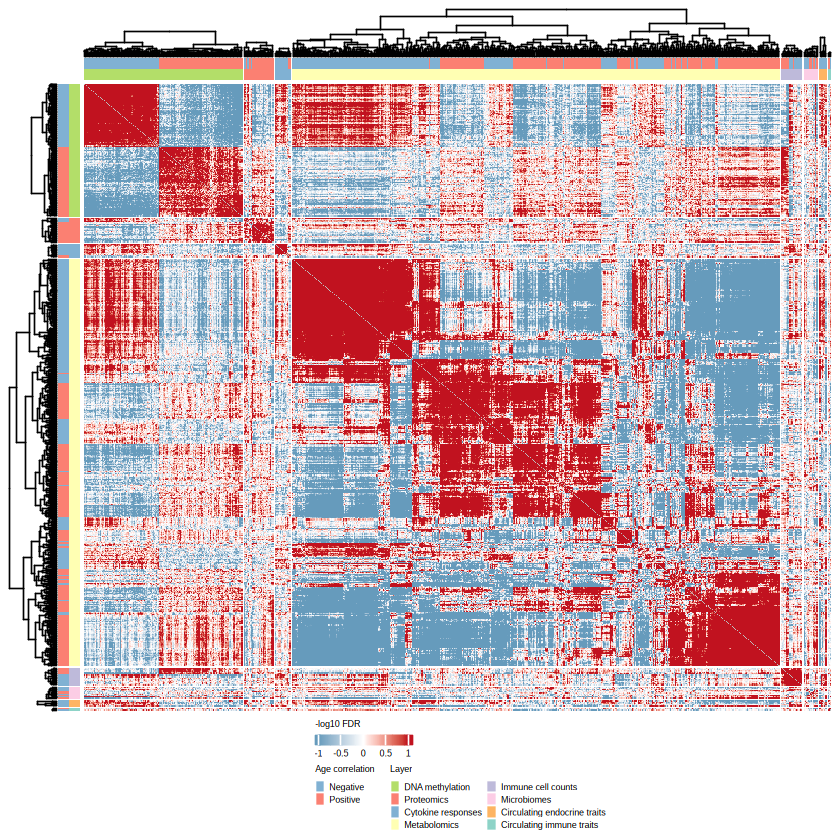

In [13]:
##nature style
# ============================================
# 1. Filter significant features from each layer
# ============================================
filter_sig <- function(df, layer, is_filtered = FALSE) {
  if (!is_filtered) df <- df[df$sig == "sig", ]
  data.frame(feature = df$feature, estimate = df$estimate, layer = layer)
}

feature_info <- rbind(
  filter_sig(methylation_filtered, "DNA methylation", TRUE),
  filter_sig(olink, "Proteomics"),
  filter_sig(cytokine, "Cytokine responses"),
  filter_sig(metabolite, "Metabolomics"),
  filter_sig(cellcounts, "Immune cell counts"),
  filter_sig(microbiome, "Microbiomes"),
  filter_sig(hormone, "Circulating endocrine traits"),
  filter_sig(immunoglobulin, "Circulating immune traits")
)

# ============================================
# 2. Select sig features from each raw data
# ============================================
select_features <- function(raw_df, sig_features) {
  cols <- colnames(raw_df)[colnames(raw_df) %in% sig_features]
  raw_df[, cols, drop = FALSE]
}

# Mvalue_sub <- select_features(Mvalue_raw, methylation_filtered$feature)
Mvalue_sub <- Mvalue_subset 
olink_sub <- select_features(olink_raw, feature_info$feature[feature_info$layer == "Proteomics"])
cytokine_sub <- select_features(cytokine_raw, feature_info$feature[feature_info$layer == "Cytokine responses"])
metabolite_sub <- select_features(metabolite_raw, feature_info$feature[feature_info$layer == "Metabolomics"])
cellcounts_sub <- select_features(cellcounts_raw, feature_info$feature[feature_info$layer == "Immune cell counts"])
microbiome_sub <- select_features(microbiome_raw, feature_info$feature[feature_info$layer == "Microbiomes"])
hormone_sub <- select_features(hormone_raw, feature_info$feature[feature_info$layer == "Circulating endocrine traits"])
immunoglobulin_sub <- select_features(immunoglobulin_raw, feature_info$feature[feature_info$layer == "Circulating immune traits"])

# ============================================
# 3. Find common samples across all datasets
# ============================================
common_samples <- Reduce(intersect, list(
  rownames(Mvalue_sub),
  rownames(olink_sub),
  rownames(cytokine_sub),
  rownames(metabolite_sub),
  rownames(cellcounts_sub),
  rownames(microbiome_sub),
  rownames(hormone_sub),
  rownames(immunoglobulin_sub)
))

cat("Number of common samples:", length(common_samples), "\n")

# ============================================
# 4. Subset to common samples and merge
# ============================================
raw_data <- cbind(
  Mvalue_sub[common_samples, ],
  olink_sub[common_samples, ],
  cytokine_sub[common_samples, ],
  metabolite_sub[common_samples, ],
  cellcounts_sub[common_samples, ],
  microbiome_sub[common_samples, ],
  hormone_sub[common_samples, ],
  immunoglobulin_sub[common_samples, ]
)

# Update feature_info to only include features that exist in raw_data
feature_info <- feature_info[feature_info$feature %in% colnames(raw_data), ]
# Fix layer order to match cbind order (so heatmap blocks match merge order)
layer_order <- c(
  "DNA methylation", "Proteomics", "Cytokine responses", "Metabolomics",
  "Immune cell counts", "Microbiomes", "Circulating endocrine traits", "Circulating immune traits"
)
feature_info$layer <- factor(feature_info$layer, levels = layer_order)
# ============================================
# 5. Calculate feature-feature correlation matrix
# ============================================
cor_matrix <- cor(raw_data, use = "pairwise.complete.obs", method = "spearman")

# ============================================
# 6. Prepare annotation information
# ===========================================

# Create layer annotation
layer_annotation <- feature_info$layer
names(layer_annotation) <- feature_info$feature

# Age correlation annotation (based on estimate sign)
age_cor <- ifelse(feature_info$estimate > 0, "Positive", "Negative")
names(age_cor) <- feature_info$feature

# Order by layer (clustering will be done within each layer)
feature_order <- feature_info$feature[order(feature_info$layer)]
cor_matrix_ordered <- cor_matrix[feature_order, feature_order]

# Get p-value for each pair from correlation (t-approximation for Spearman)
n <- nrow(raw_data)
t_stat <- cor_matrix * sqrt((n - 2) / (1 - cor_matrix^2))
t_stat[abs(cor_matrix) >= 1 | is.na(cor_matrix)] <- 0
p_matrix <- 2 * pt(-abs(t_stat), n - 2)
p_matrix[is.na(cor_matrix)] <- NA

# FDR (BH) correction over unique pairs (upper triangle only)
p_adj_matrix <- matrix(NA, nrow(p_matrix), ncol(p_matrix))
p_vec <- p_matrix[upper.tri(p_matrix)]
p_adj_vec <- p.adjust(p_vec, method = "BH")
p_adj_matrix[upper.tri(p_adj_matrix)] <- p_adj_vec
p_adj_matrix[lower.tri(p_adj_matrix)] <- t(p_adj_matrix)[lower.tri(p_adj_matrix)]
diag(p_adj_matrix) <- NA
p_adj_matrix[is.na(p_matrix)] <- NA

# Heatmap value: direction from correlation, strength from FDR -> signed -log10(FDR)
signed_logp <- sign(cor_matrix) * (-log10(p_adj_matrix))
# Avoid Inf and cap extreme -log10(p) for better color scale (e.g. p < 1e-10)
signed_logp[is.infinite(signed_logp)] <- NA
cap <- 10  # -log10(1e-10) = 10; adjust if needed
signed_logp[signed_logp > cap] <- cap
signed_logp[signed_logp < -cap] <- -cap

# Matrix for heatmap: signed -log10(p), same order
signed_logp_ordered <- signed_logp[feature_order, feature_order]

# Color scale for -log10(p) (symmetric around 0)
max_val <- max(abs(signed_logp_ordered), na.rm = TRUE)

layer_colors <- c(
  "DNA methylation" = "#B3DE69",
  "Proteomics" = "#FB8072", 
  "Cytokine responses" = "#80B1D3",
  "Metabolomics" = "#FFFFB3",
  "Immune cell counts" = "#BEBADA",
  "Microbiomes" = "#FCCDE5",
  "Circulating endocrine traits" = "#FDB462",
  "Circulating immune traits" = "#8DD3C7"
)
   
#age_colors <- c("Positive" = "#c51b7d", "Negative" = "#4575b4")
age_colors <- c("Positive" = "#FB8072", "Negative" = "#80B1D3")
# ============================================
# 8. Create heatmap
# ============================================
gp_small <- gpar(fontsize = 5)
grid_small <- unit(2, "mm") 
anno_legend_param <- list(
  `Age correlation` = list(
    title_gp = gp_small, labels_gp = gp_small,
    grid_height = grid_small, grid_width = grid_small, nrow = 2
  ),
  Layer = list(
    title_gp = gp_small, labels_gp = gp_small,
    grid_height = grid_small, grid_width = grid_small, nrow = 4
  )
)

row_ha <- rowAnnotation(
  `Age correlation` = age_cor[feature_order],
  Layer = layer_annotation[feature_order],
  col = list(`Age correlation` = age_colors, Layer = layer_colors),
  show_legend = FALSE,
  show_annotation_name = FALSE,
  annotation_name_gp = gp_small,
  simple_anno_size = unit(2, "mm")
)

col_ha <- HeatmapAnnotation(
  `Age correlation` = age_cor[feature_order],
  Layer = layer_annotation[feature_order],
  col = list(`Age correlation` = age_colors, Layer = layer_colors),
  show_legend = TRUE,
  show_annotation_name = FALSE,
  annotation_name_gp = gp_small,
  annotation_legend_param = anno_legend_param,
  simple_anno_size = unit(2, "mm")
)

col_fun <- colorRamp2(c(-1, 0, 1), c("#669bbc", "white", "#c1121f")) #4575b4 #c51b7d or #80B1D3 #FB8072 ""

ht <- Heatmap(
  signed_logp_ordered,
  name = "-log10 FDR",
  col = col_fun,
  top_annotation = col_ha,
  left_annotation = row_ha,
  show_row_names = FALSE,
  show_column_names = FALSE,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  cluster_row_slices = FALSE,
  cluster_column_slices = FALSE,
  row_split = layer_annotation[feature_order],
  column_split = layer_annotation[feature_order],
  row_title = NULL,
  column_title = NULL,
  border = FALSE,
    row_gap = unit(0.5, "mm"),
  column_gap = unit(0.5, "mm"),
  row_names_gp = gp_small,
  column_names_gp = gp_small,
  heatmap_legend_param = list(
    title_gp = gp_small,
    labels_gp = gp_small,
    legend_height = unit(20, "mm"),
    grid_height = unit(2, "mm"),
    grid_width = unit(4, "mm"),       
    direction = "horizontal"     
  )
)
w_mm <- 88
h_mm <- 110 

    # Save as PDF
pdf("/vol/projects/yzhang/500FG_aging/output/18_multi_omics_heatmap/multi_omics_heatmap_nature_gender.pdf", 
    width = w_mm / 25.4, height = h_mm / 25.4)
draw(ht,
     heatmap_legend_side = "bottom",
     annotation_legend_side = "bottom")
dev.off()
# Save as PNG
png("/vol/projects/yzhang/500FG_aging/output/18_multi_omics_heatmap/multi_omics_heatmap_nature_gender.png", 
        width = w_mm / 25.4, height = h_mm / 25.4, units = "in", res = 300)
draw(ht,
     heatmap_legend_side = "bottom",
     annotation_legend_side = "bottom")
dev.off()

draw(ht,
     heatmap_legend_side = "bottom",
     annotation_legend_side = "bottom")

In [24]:
save.image("/vol/projects/yzhang/500FG_aging/output/18_multi_omics_heatmap/multi_omics_heatmap_nature_gender.Rdata")